In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('cleaned_data_2.csv')
df.head()

,filepath,patient_name,birth_year,xray_type,datetime
0,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE AP,2024-02-26 08:47:23
1,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE AP,2024-02-26 08:47:52
2,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE AP,2024-02-26 08:48:13
3,../XQUANG\20240226\20240226014\20240226014_202...,NGUYEN DANG TUAN,1954.0,CHEST PA,2024-02-26 09:10:10
4,../XQUANG\20240226\20240226015\20240226015_202...,NGUYEN QUE,1946.0,SKULLI AP,2024-02-26 09:15:43


In [3]:
# Keep row data that empty cells in 'patient_name' or 'birth_year' or 'xray_type' columns
df_missing = df[df['patient_name'].isnull() | df['birth_year'].isnull() | df['xray_type'].isnull()]
df_missing.to_csv('missing_data.csv', index=False)

In [4]:
# Convert cells in 'xray_type' column that not contain C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT values to string empty
df_missing.loc[~df_missing['xray_type'].str.contains('C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT', na=False), 'xray_type'] = ''
df_missing.to_csv('missing_data.csv', index=False)

In [9]:
df_missing_clone = pd.read_csv('missing_data.csv')

In [10]:
# Split missing data into 2 parts: missing patient_name or birth_year and having xray_type; and missing all patient_name, birth_year and xray_type
df_missing_name_year = df_missing_clone[(df_missing_clone['patient_name'].isnull() | df_missing_clone['birth_year'].isnull()) & df_missing_clone['xray_type'].notnull()]
df_missing_all = df_missing_clone[df_missing_clone['patient_name'].isnull() & df_missing_clone['birth_year'].isnull() & df_missing_clone['xray_type'].isnull()]
df_missing_name_year.to_csv('missing_name_or_year_data.csv', index=False)
df_missing_all.to_csv('missing_all_important_data.csv', index=False)

In [3]:
df_missing_name_year = pd.read_csv('missing_name_or_year_data.csv')
df_missing_name_year.head()

,filepath,patient_name,birth_year,xray_type,datetime
0,../XQUANG\20240226\20240226017\20240226017_202...,NaN,NaN,SHOULDER,2024-02-26 09:20:01
1,../XQUANG\20240226\20240226030\20240226030_202...,NaN,NaN,CHEST PA,2024-02-26 10:36:56
2,../XQUANG\20240226\20240226031\20240226031_202...,NaN,NaN,CHEST PA,2024-02-26 10:38:21
3,../XQUANG\20240226\20240226032\20240226032_202...,NaN,NaN,SPINE LAT,2024-02-26 10:51:13
4,../XQUANG\20240226\20240226032\20240226032_202...,NaN,NaN,SPINE LAT,2024-02-26 10:52:03


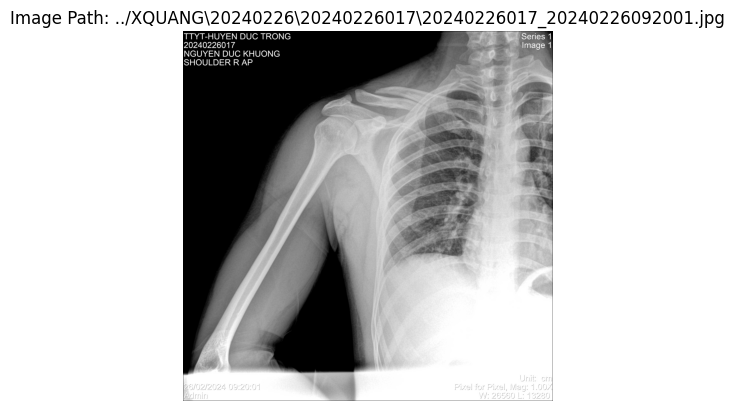

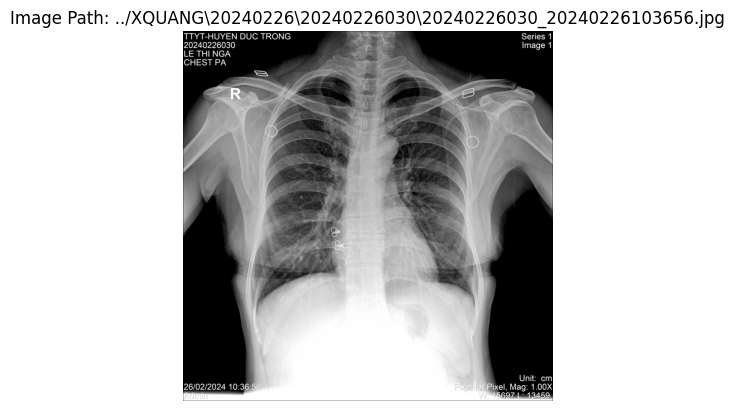

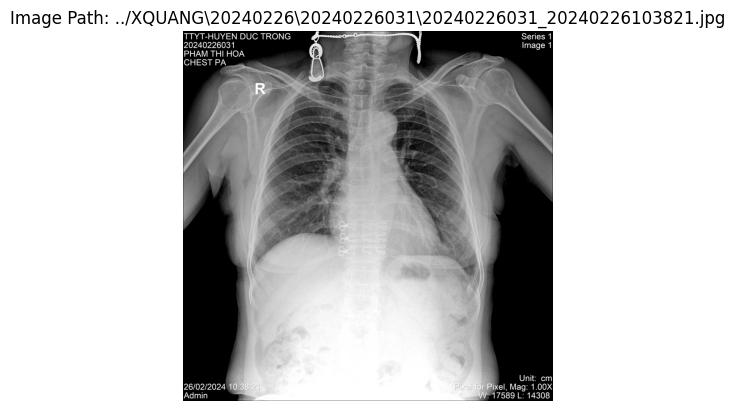

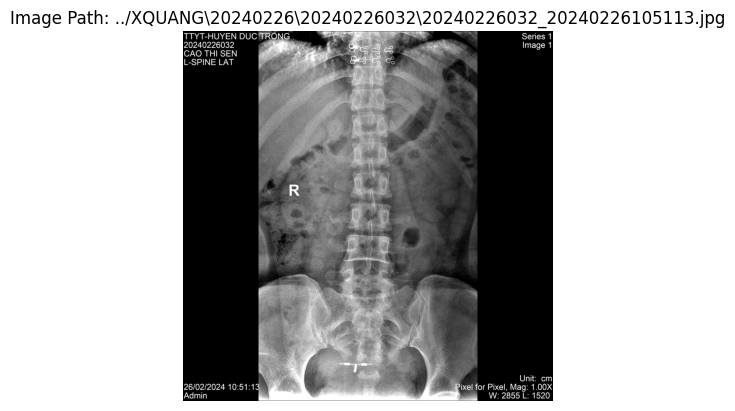

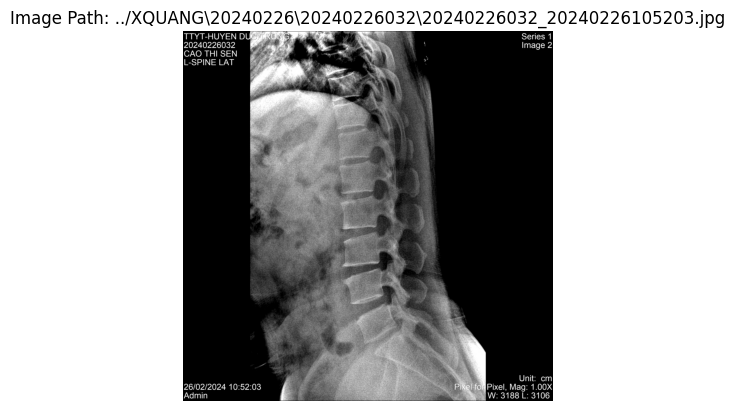

In [6]:
# Show the first images with missing patient_name or birth_year but having xray_type
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
for i in range(5):
    img_path = df_missing_name_year.iloc[i]['filepath']
    img = mpimg.imread("../" + img_path)
    plt.imshow(img, cmap='gray')
    plt.title(f"Image Path: {img_path}")
    plt.axis('off')
    plt.show()

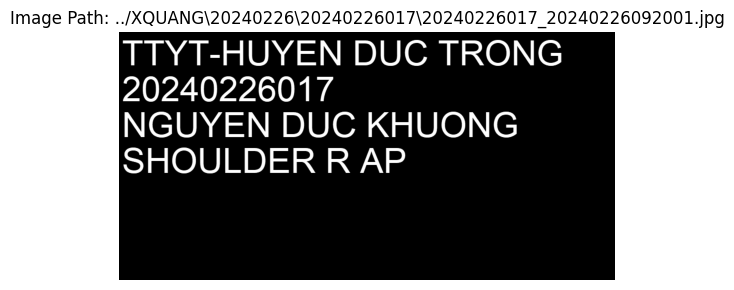

In [6]:
import cv2
for i in range(1):
    img_path = df_missing_name_year.iloc[i]['filepath']
    img = cv2.imread("../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Crop the image to focus on the main area (example values, adjust as needed)
    gray = gray[0:500, 0:1000]
    plt.imshow(gray, cmap='gray')
    plt.title(f"Image Path: {img_path}")
    plt.axis('off')
    plt.show()

In [4]:
len(df_missing_name_year)

4590

In [ ]:
# Extract text from images with missing patient_name or birth_year but having xray_type using OCR (Optical Character Recognition) (not use pytesseract)
import cv2
import numpy as np
import easyocr
reader = easyocr.Reader(['en'])
for i in range(len(df_missing_name_year)):
    img_path = df_missing_name_year.iloc[i]['filepath']
    img = cv2.imread("../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray[0:500, 0:1000]
    results = reader.readtext(gray)
    patient_name = str(results[2][1])
    # Update the 'patient_name' column in the dataframe
    df_missing_name_year.at[i, 'patient_name'] = patient_name
    print(f"{i + 1}: Extracted patient_name: {patient_name} from image: {img_path}")

df_missing_name_year.to_csv('missing_name_or_year_data_filled.csv', index=False)


C:\Users\Hieu\AppData\Local\Temp\ipykernel_23804\131544270.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NGUYEN DUC KHUONG' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_missing_name_year.at[i, 'patient_name'] = patient_name


1: Extracted patient_name: NGUYEN DUC KHUONG from image: ../XQUANG\20240226\20240226017\20240226017_20240226092001.jpg
2: Extracted patient_name: LE THI NGA from image: ../XQUANG\20240226\20240226030\20240226030_20240226103656.jpg
3: Extracted patient_name: PHAM THI HOA from image: ../XQUANG\20240226\20240226031\20240226031_20240226103821.jpg
4: Extracted patient_name: CAO THI SEN from image: ../XQUANG\20240226\20240226032\20240226032_20240226105113.jpg
5: Extracted patient_name: CAO THI SEN from image: ../XQUANG\20240226\20240226032\20240226032_20240226105203.jpg
6: Extracted patient_name: LE HUU AI2000 from image: ../XQUANG\20240226\20240226035\20240226035_20240226114853.jpg
7: Extracted patient_name: TRAN HOANG HAI from image: ../XQUANG\20240226\20240226050\20240226050_20240226154614.jpg
8: Extracted patient_name: TRAN THI TIEN 74 from image: ../XQUANG\20240227\20240227012\20240227012_20240227084610.jpg
9: Extracted patient_name: DINH VAN THIA BAO from image: ../XQUANG\20240227\2024

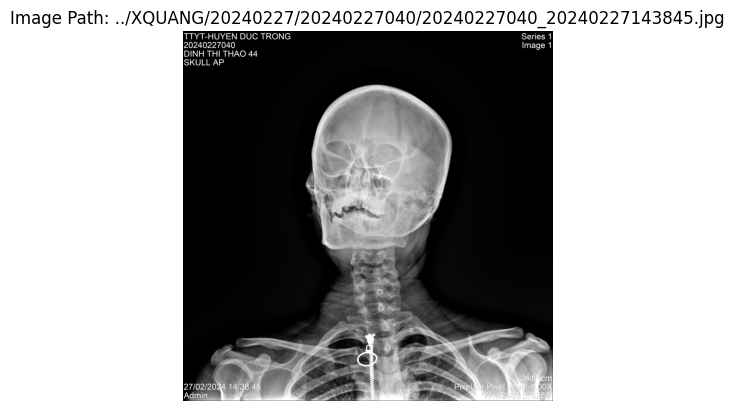

In [8]:
img_path = '../XQUANG/20240227/20240227040/20240227040_20240227143845.jpg'
img = mpimg.imread("../" + img_path)
plt.imshow(img, cmap='gray')
plt.title(f"Image Path: {img_path}")
plt.axis('off')
plt.show()

In [12]:
df_missing_name_year_filled = pd.read_csv('missing_name_or_year_data_filled.csv')
df_missing_name_year_filled.head()

,filepath,patient_name,birth_year,xray_type,datetime
0,../XQUANG\20240226\20240226017\20240226017_202...,NGUYEN DUC KHUONG,NaN,SHOULDER,2024-02-26 09:20:01
1,../XQUANG\20240226\20240226030\20240226030_202...,LE THI NGA,NaN,CHEST PA,2024-02-26 10:36:56
2,../XQUANG\20240226\20240226031\20240226031_202...,PHAM THI HOA,NaN,CHEST PA,2024-02-26 10:38:21
3,../XQUANG\20240226\20240226032\20240226032_202...,CAO THI SEN,NaN,SPINE LAT,2024-02-26 10:51:13
4,../XQUANG\20240226\20240226032\20240226032_202...,CAO THI SEN,NaN,SPINE LAT,2024-02-26 10:52:03


In [14]:
# Remove number, special characters from 'patient_name' column and uppercase all letters
df_missing_name_year_filled['patient_name'] = df_missing_name_year_filled['patient_name'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.upper()
df_missing_name_year_filled.head()
df_missing_name_year_filled.to_csv('missing_name_or_year_data_filled.csv', index=False)

In [17]:
import pandas as pd

# 1. Đọc dữ liệu từ 2 file csv
# Giả sử file bị thiếu là 'file_thieu.csv' và file dùng để fill là 'file_fill.csv'
df_missing = pd.read_csv('cleaned_data_2.csv')
df_full = pd.read_csv('missing_name_or_year_data_filled.csv')

# 2. Thiết lập cột 'filepath' làm index (chỉ mục) cho cả 2 dataframe
# Bước này cực kỳ quan trọng để pandas biết dòng nào khớp với dòng nào
df_missing.set_index('filepath', inplace=True)
df_full.set_index('filepath', inplace=True)

# 3. Sử dụng combine_first để điền dữ liệu
# Logic: Giữ nguyên dữ liệu của df_missing, CHỈ KHI NÀO gặp giá trị trống (NaN)
# thì mới lấy giá trị tương ứng từ df_full đắp vào.
df_result = df_missing.combine_first(df_full)

# 4. Reset index để đưa 'filepath' quay trở lại thành một cột bình thường
df_result.reset_index(inplace=True)

# (Tuỳ chọn) Định dạng lại cột birth_year
# Khi đọc file có dữ liệu trống, pandas thường chuyển số thành dạng float (vd: 1990.0)
# Dòng này giúp chuyển lại về số nguyên (1990) nếu muốn đẹp hơn
# Lưu ý: Chỉ chạy được dòng này nếu sau khi merge cột birth_year không còn ô nào trống
if df_result['birth_year'].isnull().sum() == 0:
    df_result['birth_year'] = df_result['birth_year'].astype(int)

# 5. Lưu ra file mới
df_result.to_csv('cleaned_data_3.csv', index=False)

---

In [19]:
import pandas as pd

df_3 = pd.read_csv('cleaned_data_3.csv')
df_3.head()

# Keep row data that empty cells in 'patient_name' or 'birth_year' or 'xray_type' columns
df_3_missing = df_3[df_3['patient_name'].isnull() | df_3['birth_year'].isnull() | df_3['xray_type'].isnull()]
df_3_missing.to_csv('3/missing_data.csv', index=False)

# Convert cells in 'xray_type' column that not contain C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT values to string empty
df_3_missing.loc[~df_3_missing['xray_type'].str.contains('C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT', na=False), 'xray_type'] = ''
df_3_missing.to_csv('3/missing_data.csv', index=False)

df_3_missing_clone = pd.read_csv('3/missing_data.csv')

# Split missing data into 2 parts: missing patient_name or birth_year and having xray_type; and missing all patient_name, birth_year and xray_type
df_3_missing_name_year = df_3_missing_clone[(df_3_missing_clone['patient_name'].isnull() | df_3_missing_clone['birth_year'].isnull()) & df_3_missing_clone['xray_type'].notnull()]
df_3_missing_all = df_3_missing_clone[df_3_missing_clone['patient_name'].isnull() & df_3_missing_clone['birth_year'].isnull() & df_3_missing_clone['xray_type'].isnull()]
df_3_missing_name_year.to_csv('3/missing_name_or_year_data.csv', index=False)
df_3_missing_all.to_csv('3/missing_all_important_data.csv', index=False)

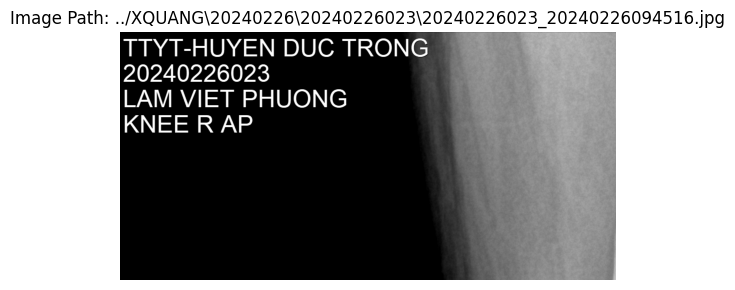

In [20]:
import cv2
for i in range(1):
    img_path = df_3_missing_all.iloc[i]['filepath']
    img = cv2.imread("../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Crop the image to focus on the main area (example values, adjust as needed)
    gray = gray[0:500, 0:1000]
    plt.imshow(gray, cmap='gray')
    plt.title(f"Image Path: {img_path}")
    plt.axis('off')
    plt.show()

In [26]:
import easyocr
reader = easyocr.Reader(['en'])
df_3_missing_all = pd.read_csv('3/missing_all_data_filled.csv')
for i in range(1420, len(df_3_missing_all)):
    img_path = df_3_missing_all.iloc[i]['filepath']
    img = cv2.imread("../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray[0:500, 0:1000]
    results = reader.readtext(gray)
    patient_name = str(results[2][1])
    x_ray_type = str(results[3][1])
    df_3_missing_all.at[i, 'patient_name'] = patient_name
    df_3_missing_all.at[i, 'xray_type'] = x_ray_type
    print(f"{i + 1}: Extracted patient_name: {patient_name} - x-ray type: {x_ray_type} - from image: {img_path}")

df_3_missing_all.to_csv('3/missing_all_data_filled.csv', index=False)

1421: Extracted patient_name: LE DIEM THUY - x-ray type: WRIST RAP - from image: ../XQUANG\20240723\20240723057\20240723057_20240723165818.jpg
1422: Extracted patient_name: LE DIEM THUY - x-ray type: WRIST RAP - from image: ../XQUANG\20240723\20240723057\20240723057_20240723165836.jpg
1423: Extracted patient_name: LE DIEM THUY - x-ray type: HAND LAP - from image: ../XQUANG\20240723\20240723057\20240723057_20240723165909.jpg
1424: Extracted patient_name: LE DIEM THUY - x-ray type: HAND LAP - from image: ../XQUANG\20240723\20240723057\20240723057_20240723165925.jpg
1425: Extracted patient_name: MAI VAN TUAN ANH - x-ray type: ANKLE RAP - from image: ../XQUANG\20240723\20240723062\20240723062_20240723193909.jpg
1426: Extracted patient_name: MAI VAN TUAN ANH - x-ray type: ANKLE RAP - from image: ../XQUANG\20240723\20240723062\20240723062_20240723193936.jpg
1427: Extracted patient_name: HOANG MONG CAT TIEN - x-ray type: KNEE RAP - from image: ../XQUANG\20240723\20240723064\20240723064_202407

In [28]:
df_3_missing_all_filled = pd.read_csv('3/missing_all_data_filled.csv')
df_3_missing_all_filled['patient_name'] = df_3_missing_all_filled['patient_name'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.upper()
df_3_missing_all_filled.head()
df_3_missing_all_filled.to_csv('3/missing_all_data_filled.csv', index=False)

In [29]:
import pandas as pd

# 1. Đọc dữ liệu từ 2 file csv
# Giả sử file bị thiếu là 'file_thieu.csv' và file dùng để fill là 'file_fill.csv'
df_missing = pd.read_csv('cleaned_data_3.csv')
df_full = pd.read_csv('3/missing_all_data_filled.csv')

# 2. Thiết lập cột 'filepath' làm index (chỉ mục) cho cả 2 dataframe
# Bước này cực kỳ quan trọng để pandas biết dòng nào khớp với dòng nào
df_missing.set_index('filepath', inplace=True)
df_full.set_index('filepath', inplace=True)

# 3. Sử dụng combine_first để điền dữ liệu
# Logic: Giữ nguyên dữ liệu của df_missing, CHỈ KHI NÀO gặp giá trị trống (NaN)
# thì mới lấy giá trị tương ứng từ df_full đắp vào.
df_result = df_missing.combine_first(df_full)

# 4. Reset index để đưa 'filepath' quay trở lại thành một cột bình thường
df_result.reset_index(inplace=True)

# (Tuỳ chọn) Định dạng lại cột birth_year
# Khi đọc file có dữ liệu trống, pandas thường chuyển số thành dạng float (vd: 1990.0)
# Dòng này giúp chuyển lại về số nguyên (1990) nếu muốn đẹp hơn
# Lưu ý: Chỉ chạy được dòng này nếu sau khi merge cột birth_year không còn ô nào trống
if df_result['birth_year'].isnull().sum() == 0:
    df_result['birth_year'] = df_result['birth_year'].astype(int)

# 5. Lưu ra file mới
df_result.to_csv('cleaned_data_4.csv', index=False)

---

In [30]:
import pandas as pd

df_4 = pd.read_csv('cleaned_data_4.csv')
df_4.head()

# Keep row data that empty cells in 'patient_name' or 'birth_year' or 'xray_type' columns
df_4_missing = df_4[df_4['patient_name'].isnull() | df_4['birth_year'].isnull() | df_4['xray_type'].isnull()]
df_4_missing.to_csv('4/missing_data.csv', index=False)

# Convert cells in 'xray_type' column that not contain C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT values to string empty
df_4_missing.loc[~df_4_missing['xray_type'].str.contains('C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT', na=False), 'xray_type'] = ''
df_4_missing.to_csv('4/missing_data.csv', index=False)

df_4_missing_clone = pd.read_csv('4/missing_data.csv')

# Split missing data into 2 parts: missing patient_name or birth_year and having xray_type; and missing all patient_name, birth_year and xray_type
df_4_missing_name_year = df_4_missing_clone[(df_4_missing_clone['patient_name'].isnull() | df_4_missing_clone['birth_year'].isnull()) & df_4_missing_clone['xray_type'].notnull()]
df_4_missing_all = df_4_missing_clone[df_4_missing_clone['patient_name'].isnull() & df_4_missing_clone['birth_year'].isnull() & df_4_missing_clone['xray_type'].isnull()]
df_4_missing_name_year.to_csv('4/missing_name_or_year_data.csv', index=False)
df_4_missing_all.to_csv('4/missing_all_important_data.csv', index=False)

In [5]:
import pandas as pd
import cv2
import easyocr
reader = easyocr.Reader(['en'])
df_4_missing_all = pd.read_csv('4/missing_all_important_data.csv')
for i in range(len(df_4_missing_all)):
    img_path = df_4_missing_all.iloc[i]['filepath']
    img = cv2.imread("../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray[0:500, 0:1000]
    results = reader.readtext(gray)
    patient_name = str(results[2][1])
    x_ray_type = str(results[3][1])
    df_4_missing_all.at[i, 'patient_name'] = patient_name
    df_4_missing_all.at[i, 'xray_type'] = x_ray_type
    print(f"{i + 1}: Extracted patient_name: {patient_name} - x-ray type: {x_ray_type} - from image: {img_path}")

df_4_missing_all.to_csv('4/missing_all_data_filled.csv', index=False)

C:\Users\Hieu\AppData\Local\Temp\ipykernel_14392\4250349221.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'LE VAN HUNG' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_4_missing_all.at[i, 'patient_name'] = patient_name
C:\Users\Hieu\AppData\Local\Temp\ipykernel_14392\4250349221.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'KNEE RAP' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_4_missing_all.at[i, 'xray_type'] = x_ray_type


1: Extracted patient_name: LE VAN HUNG - x-ray type: KNEE RAP - from image: ../XQUANG\20240423\20240422057\20240422057_20240422220851.jpg
2: Extracted patient_name: NGUYEN DANG QUANG - x-ray type: KNEE RAP - from image: ../XQUANG\20240527\20240527051\20240527051_20240527173717.jpg
3: Extracted patient_name: rigoc tkiu - x-ray type: CHEST PA - from image: ../XQUANG\20240528\20240528042\20240528042_20240528141316.jpg
4: Extracted patient_name: 20240727021 - x-ray type: Image 2 - from image: ../XQUANG\20240728\20240727021\20240727021_20240727214303.jpg
5: Extracted patient_name: 4075 - x-ray type: TRAN MA TUYEN - from image: ../XQUANG\20240814\20240814075\20240814075_20240814204837.jpg
6: Extracted patient_name: 20240923004 - x-ray type: HIUA THI HONG - from image: ../XQUANG\20240923\20240923004\20240923004_20240923081557.jpg
7: Extracted patient_name: 20240925026 - x-ray type: NGUYENTTUAN TAI 1957 - from image: ../XQUANG\20240925\20240925026\20240925026_20240925102548.jpg
8: Extracted pa

In [6]:
df_4_missing_all_filled = pd.read_csv('4/missing_all_data_filled.csv')
df_4_missing_all_filled['patient_name'] = df_4_missing_all_filled['patient_name'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.upper()
df_4_missing_all_filled.head()
df_4_missing_all_filled.to_csv('4/missing_all_data_filled.csv', index=False)

In [7]:
import pandas as pd

# 1. Đọc dữ liệu từ 2 file csv
# Giả sử file bị thiếu là 'file_thieu.csv' và file dùng để fill là 'file_fill.csv'
df_missing = pd.read_csv('cleaned_data_4.csv')
df_full = pd.read_csv('4/missing_all_data_filled.csv')

# 2. Thiết lập cột 'filepath' làm index (chỉ mục) cho cả 2 dataframe
# Bước này cực kỳ quan trọng để pandas biết dòng nào khớp với dòng nào
df_missing.set_index('filepath', inplace=True)
df_full.set_index('filepath', inplace=True)

# 3. Sử dụng combine_first để điền dữ liệu
# Logic: Giữ nguyên dữ liệu của df_missing, CHỈ KHI NÀO gặp giá trị trống (NaN)
# thì mới lấy giá trị tương ứng từ df_full đắp vào.
df_result = df_missing.combine_first(df_full)

# 4. Reset index để đưa 'filepath' quay trở lại thành một cột bình thường
df_result.reset_index(inplace=True)

# (Tuỳ chọn) Định dạng lại cột birth_year
# Khi đọc file có dữ liệu trống, pandas thường chuyển số thành dạng float (vd: 1990.0)
# Dòng này giúp chuyển lại về số nguyên (1990) nếu muốn đẹp hơn
# Lưu ý: Chỉ chạy được dòng này nếu sau khi merge cột birth_year không còn ô nào trống
if df_result['birth_year'].isnull().sum() == 0:
    df_result['birth_year'] = df_result['birth_year'].astype(int)

# 5. Lưu ra file mới
df_result.to_csv('cleaned_data_5.csv', index=False)

---

In [8]:
import pandas as pd

df_5 = pd.read_csv('cleaned_data_5.csv')
df_5.head()

# Keep row data that empty cells in 'patient_name' or 'birth_year' or 'xray_type' columns
df_5_missing = df_5[df_5['patient_name'].isnull() | df_5['birth_year'].isnull() | df_5['xray_type'].isnull()]
df_5_missing.to_csv('5/missing_data.csv', index=False)

# Convert cells in 'xray_type' column that not contain C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT values to string empty
df_5_missing.loc[~df_5_missing['xray_type'].str.contains('C-SPINE|CERVICAL|CHEST|THORAX|L-SPINE|T-SPINE|KUB|ABDOMEN|PELVIS|KNEE|SHOULDER|AP|LAT', na=False), 'xray_type'] = ''
df_5_missing.to_csv('5/missing_data.csv', index=False)

df_5_missing_clone = pd.read_csv('5/missing_data.csv')

# Split missing data into 2 parts: missing patient_name or birth_year and having xray_type; and missing all patient_name, birth_year and xray_type
df_5_missing_name_year = df_5_missing_clone[(df_5_missing_clone['patient_name'].isnull() | df_5_missing_clone['birth_year'].isnull()) & df_5_missing_clone['xray_type'].notnull()]
df_5_missing_all = df_5_missing_clone[df_5_missing_clone['patient_name'].isnull() & df_5_missing_clone['birth_year'].isnull() & df_5_missing_clone['xray_type'].isnull()]
df_5_missing_name_year.to_csv('5/missing_name_or_year_data.csv', index=False)
df_5_missing_all.to_csv('5/missing_all_important_data.csv', index=False)